In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
env = gym.make('FrozenLake-v1', is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"Number of states: {n_states}")
print(f"Number of actions: {n_actions}")

Number of states: 16
Number of actions: 4


In [3]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()  # Explore: choose a random action
    else:
        return np.argmax(Q[state, :])  # Exploit: choose the best known action

In [5]:
# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode



In [6]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

epsilon = epsilon_start

for i_episode in range(num_episodes):
    episode = generate_episode(epsilon)

    # Total reward for the episode
    total_reward = sum([reward for state, action, reward in episode])
    episode_rewards.append(total_reward)

    # Update Q-table
    G = 0  # Discounted return
    for t in reversed(range(len(episode))):
        state, action, reward = episode[t]
        G = reward + gamma * G

        # Check if (state, action) pair has been visited for the first time in this episode
        # This is a common simplification for Monte Carlo control
        first_occurrence = next(i for i, (s, a, r) in enumerate(episode) if s == state and a == action)
        if first_occurrence == t:
            # Simple average or incremental update
            Q[state, action] = Q[state, action] + alpha * (G - Q[state, action])

    # Epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (i_episode + 1) % 1000 == 0:
        print(f"Episode {i_episode + 1}/{num_episodes}, Epsilon: {epsilon:.4f}, Avg Reward: {np.mean(episode_rewards[-1000:]):.2f}")

Episode 1000/20000, Epsilon: 0.6065, Avg Reward: 0.09
Episode 2000/20000, Epsilon: 0.3678, Avg Reward: 0.40
Episode 3000/20000, Epsilon: 0.2230, Avg Reward: 0.64
Episode 4000/20000, Epsilon: 0.1353, Avg Reward: 0.80
Episode 5000/20000, Epsilon: 0.0820, Avg Reward: 0.87
Episode 6000/20000, Epsilon: 0.0500, Avg Reward: 0.93
Episode 7000/20000, Epsilon: 0.0500, Avg Reward: 0.94
Episode 8000/20000, Epsilon: 0.0500, Avg Reward: 0.94
Episode 9000/20000, Epsilon: 0.0500, Avg Reward: 0.93
Episode 10000/20000, Epsilon: 0.0500, Avg Reward: 0.94
Episode 11000/20000, Epsilon: 0.0500, Avg Reward: 0.92
Episode 12000/20000, Epsilon: 0.0500, Avg Reward: 0.95
Episode 13000/20000, Epsilon: 0.0500, Avg Reward: 0.93
Episode 14000/20000, Epsilon: 0.0500, Avg Reward: 0.94
Episode 15000/20000, Epsilon: 0.0500, Avg Reward: 0.93
Episode 16000/20000, Epsilon: 0.0500, Avg Reward: 0.93
Episode 17000/20000, Epsilon: 0.0500, Avg Reward: 0.94
Episode 18000/20000, Epsilon: 0.0500, Avg Reward: 0.95
Episode 19000/20000

In [7]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [8]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name:          ")
    print("Register Number:      ")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.615 0.842 0.488 0.527]
 [0.611 0.    0.59  0.566]
 [0.583 0.701 0.703 0.697]
 [0.71  0.    0.324 0.504]
 [0.558 0.878 0.    0.531]
 [0.    0.    0.    0.   ]
 [0.    0.979 0.    0.819]
 [0.    0.    0.    0.   ]
 [0.741 0.    0.908 0.715]
 [0.772 0.762 0.973 0.   ]
 [0.853 0.989 0.    0.894]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.812 0.947 0.818]
 [0.931 0.99  1.    0.958]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.842 0.611 0.703 0.71 ]
 [0.878 0.    0.979 0.   ]
 [0.908 0.973 0.989 0.   ]
 [0.    0.947 1.    0.   ]]
Name:          
Register Number:      

Learned Policy:
[['D' 'L' 'R' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.919


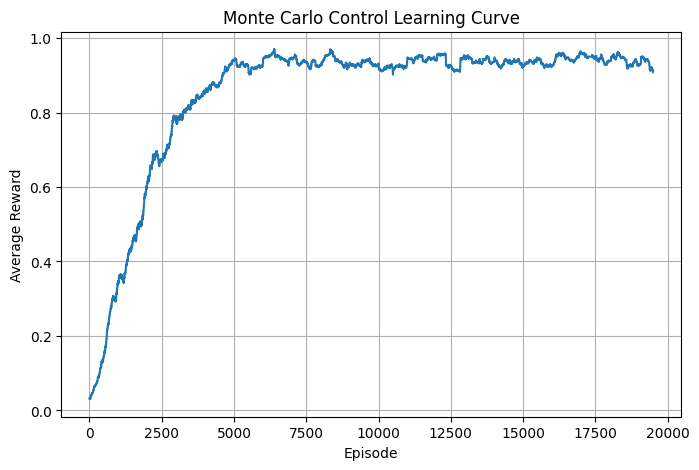

In [9]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()